# Iris Flower Classification

## 1. Introduction

This project builds a machine learning classification system to identify iris flower species based on their physical measurements.

The dataset contains three species:

- Setosa
- Versicolor
- Virginica

The four input features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The workflow includes exploratory data analysis, visualization, feature analysis, train-test splitting, model training, evaluation, and comparison of two classification algorithms: Logistic Regression and Decision Tree.

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

## 3. Load the Iris Dataset

In [3]:
iris = load_iris()

In [4]:
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [5]:
print(iris.data.shape)

(150, 4)


In [6]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [8]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


## 4. Create a Pandas DataFrame

In [10]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

In [11]:
df["species"] = iris.target

In [12]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## 5. Exploratory Data Analysis (EDA)

In [14]:
df.shape

(150, 5)

In [15]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

In [16]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [17]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
df["species"].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

## 6. Data Visualization

### Pairplot of Iris Features

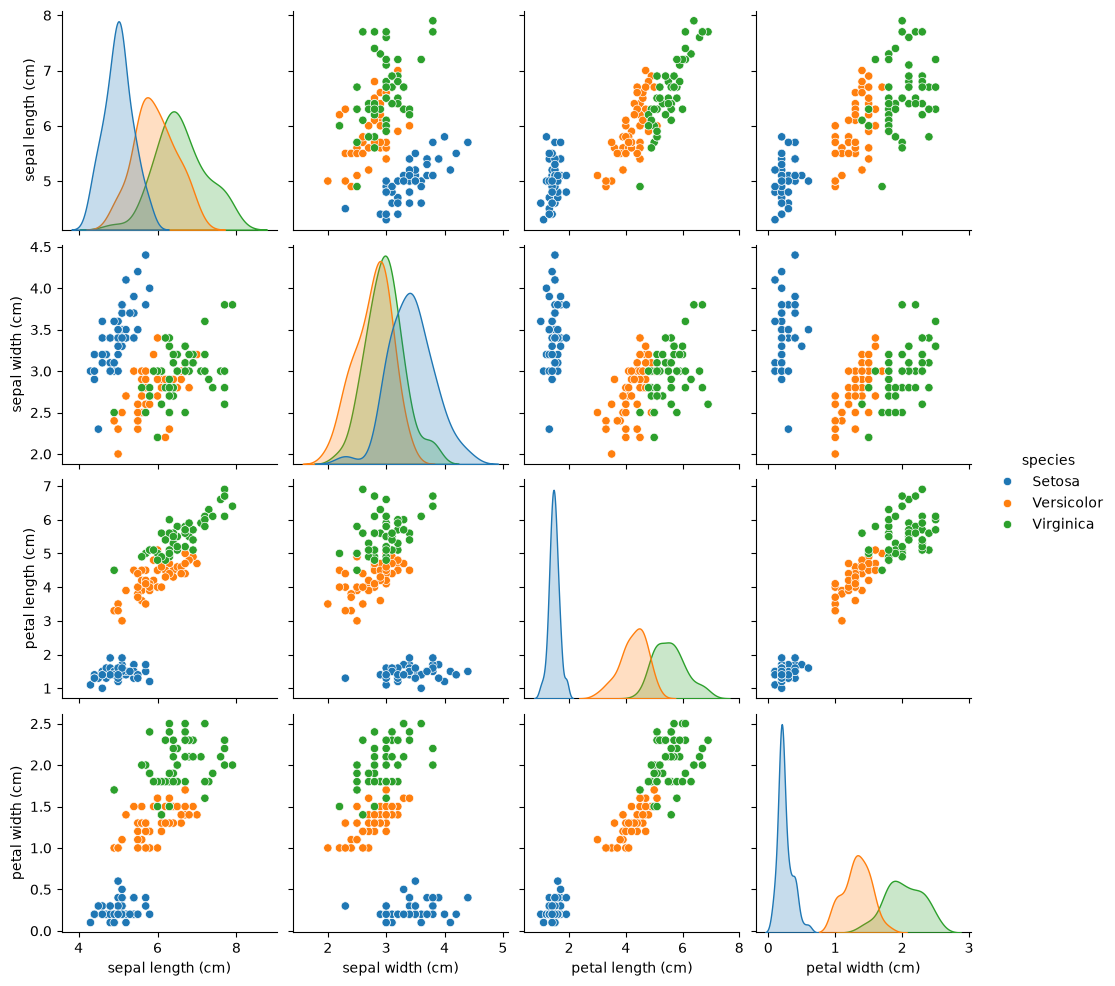

In [19]:
sns.pairplot(df, hue="species")

plt.show()

### Observation

The pairplot shows that petal length and petal width provide strong separation between the iris species. Setosa forms a clearly distinct cluster, while Versicolor and Virginica show comparatively more overlap. This suggests that petal-related features may be particularly useful for classification.

### Box Plots by Species

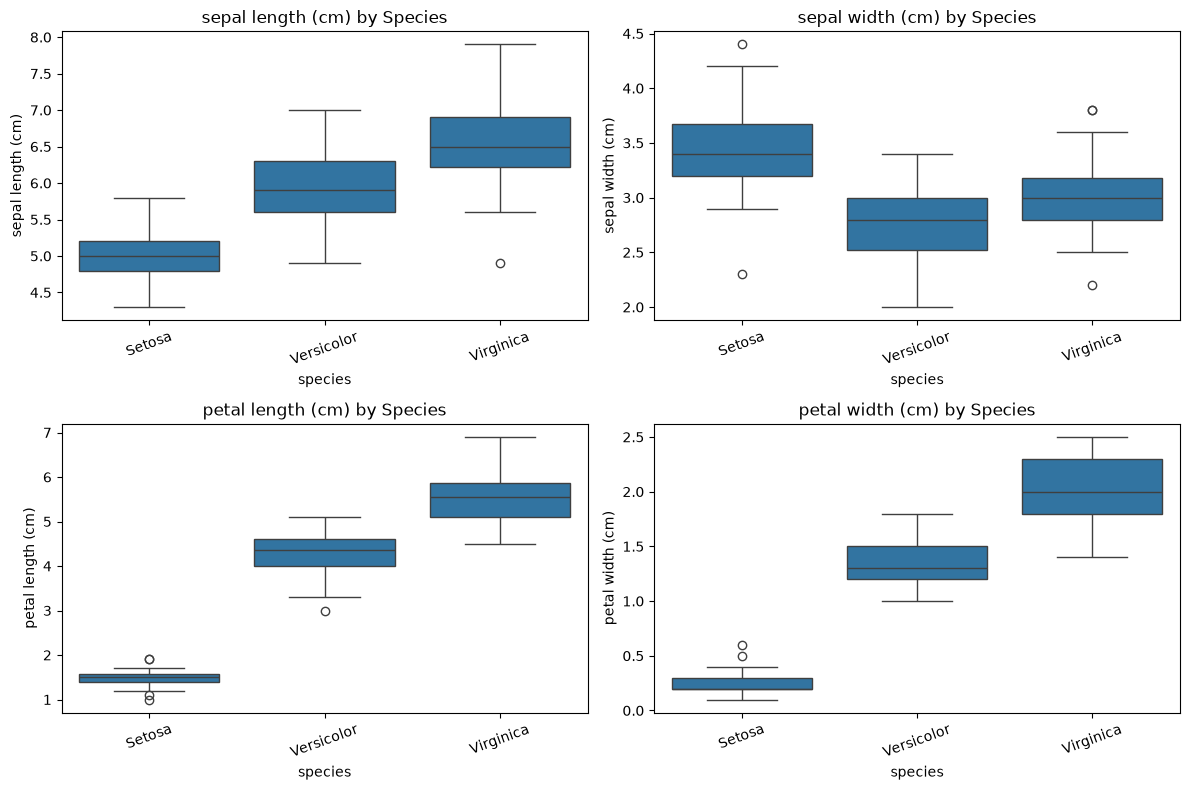

In [20]:
plt.figure(figsize=(12, 8))

for i, column in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species", y=column)
    plt.title(f"{column} by Species")
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Box Plot Observation

The box plots show clear differences in petal length and petal width across the three species. Setosa has substantially smaller petal measurements compared with Versicolor and Virginica. The sepal measurements show more overlap between species. These observations suggest that petal length and petal width are particularly discriminative features.

## 7. Preparing Data for Machine Learning

In [21]:
X = df[iris.feature_names]

In [22]:
X = df[iris.feature_names]

In [23]:
y = iris.target

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


### Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


## 8. Model 1 — Logistic Regression


In [28]:
from sklearn.linear_model import LogisticRegression


In [29]:
logistic_model = LogisticRegression(max_iter=200)


In [30]:
logistic_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [31]:
y_pred_logistic = logistic_model.predict(X_test)

In [32]:
print("Predicted:", y_pred_logistic)
print("Actual:   ", y_test)

Predicted: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Actual:    [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


## 9. Model Evaluation — Logistic Regression

### Accuracy

from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

### Confusion Matrix

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistic)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


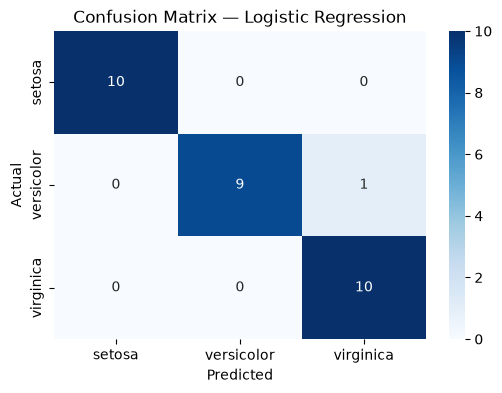

In [37]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

### Precision, Recall and F1-Score

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [41]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


In [42]:

from sklearn.metrics import precision_score, recall_score, f1_score

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613


## 10. Model 2 — Decision Tree Classifier

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
decision_tree = DecisionTreeClassifier(random_state=42)

In [45]:
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [46]:
y_pred_tree = decision_tree.predict(X_test)

In [47]:
print("Predicted:", y_pred_tree)
print("Actual:   ", y_test)

Predicted: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Actual:    [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


## 11. Model Evaluation — Decision Tree

### Accuracy

In [48]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9333333333333333


### Confusion Matrix

In [49]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


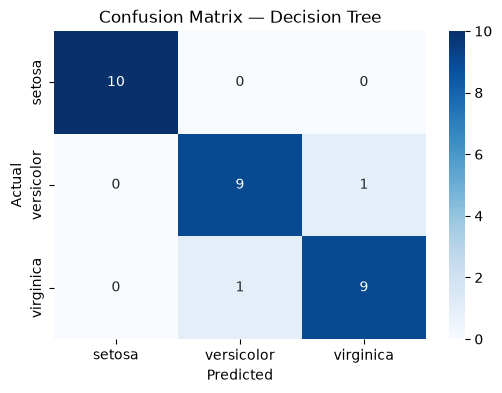

In [50]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Decision Tree")
plt.show()

### Precision, Recall and F1-Score

In [51]:
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [52]:
tree_precision = precision_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)

Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1 Score : 0.9333333333333333


## 12. Model Comparison


In [53]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy],
    "Precision": [logistic_precision, tree_precision],
    "Recall": [logistic_recall, tree_recall],
    "F1 Score": [logistic_f1, tree_f1]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.966667,0.969697,0.966667,0.966583
1,Decision Tree,0.933333,0.933333,0.933333,0.933333


In [54]:
best_model = model_comparison.loc[
    model_comparison["F1 Score"].idxmax(),
    "Model"
]

print("Best Performing Model:", best_model)

Best Performing Model: Logistic Regression


In [55]:
best_f1 = model_comparison["F1 Score"].max()

print("Best F1 Score:", best_f1)

Best F1 Score: 0.9665831244778613


### Best Model Selection

The two classification models, Logistic Regression and Decision Tree, were evaluated using accuracy, precision, recall, and F1-score.

Based on the evaluation results, **Logistic Regression** performed better overall. It achieved the highest F1-score of **0.9666**, indicating a strong balance between precision and recall.

Therefore, **Logistic Regression is selected as the best-performing model** for the Iris flower classification task.

## 13. Feature Importance Analysis

In [56]:
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,petal length (cm),0.558568
3,petal width (cm),0.406015
1,sepal width (cm),0.029167
0,sepal length (cm),0.006250


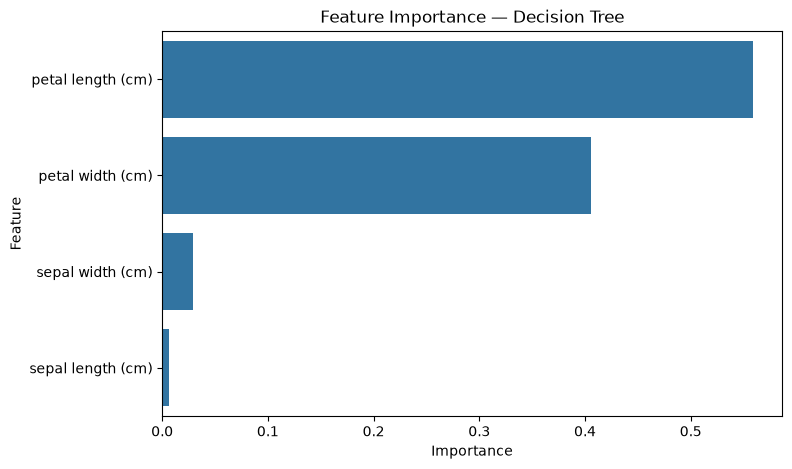

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature Selection Discussion

The feature importance analysis indicates that the petal-related features are among the most informative features for distinguishing the three iris species. This is consistent with the earlier pairplot and box plot observations, where petal length and petal width showed stronger separation between species than the sepal measurements.

Therefore, petal length and petal width can be considered particularly discriminative features for this classification problem.

### Feature Importance Observation

The Decision Tree feature importance analysis shows that **petal length** is the most important feature, followed by **petal width**. The two petal-related features contribute substantially more to the model's decisions than the sepal features.

This finding is consistent with the earlier pairplot and box plot analysis, where petal length and petal width showed clearer separation between the iris species.

Therefore, **petal length and petal width are the most discriminative features** for this classification task.

## 14. Conclusion

This project successfully developed a machine learning solution for classifying iris flowers into Setosa, Versicolor, and Virginica.

Exploratory data analysis and visualization showed that petal-related measurements provide strong separation between the three species. The feature importance analysis further identified petal length and petal width as the most influential features for the Decision Tree model.

Two classification algorithms, Logistic Regression and Decision Tree, were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

Based on the evaluation results, Logistic Regression was selected as the best-performing model, achieving an F1-score of 0.9666.

Overall, the project demonstrates a complete machine learning workflow from data exploration and visualization to model training, evaluation, feature analysis, and model selection.